# 09 · Gender Networks: Cast-Adjusted Homophily and Method Validation

**Two-pillar structure:**

- **Pillar A** (§1–3) — *The Measure.* Does the cast-adjusted protagonist homophily z remove the spurious raw gender gap?
- **Pillar B** (§4–5) — *The Method.* When does LLM-tagged addressee data add value over cheap scene co-occurrence?

**Sample:** N=17 (8 F-led + 9 M-led). Soul dropped; Monsters Inc = Sulley. Source: `film_features_all_n17.csv`.

---
### How to read every figure
- **`protag_samesex` (raw):** share of protagonist dialogue spoken to same-gender characters (0–1).
- **`protag_samesex_z` (cast-adjusted):** standard deviations above/below what the protagonist's own cast composition would predict by chance.
  - **z = 0** → exactly what the cast makes available (the meaningful reference, not 0 or 1).
  - **z > 0** → talks to own gender *more* than chance; **z < 0** → *less* than chance.
- The thesis claim lives in the **contrast**: a large raw gap that disappears after cast adjustment → the gap was cast composition, not protagonist behaviour.

In [2]:
from pathlib import Path
import subprocess, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import spearmanr

CLEAN = Path('..').resolve()
sys.path.insert(0, str(CLEAN / 'analysis' / 'h1_homophily'))
from _common import (GENDER_PALETTE, GENDER_ORDER, RNG_SEED,
                     mannwhitney, cliffs_delta, perm_test_diff, bootstrap_diff_ci,
                     rank_biserial, set_style, power_note)
set_style()

DATA = CLEAN / 'data' / '02_processed'
TBL  = CLEAN / 'analysis' / 'h1_homophily' / 'tables_n17'
FIG  = CLEAN / 'analysis' / 'h1_homophily' / 'figures_n17'
FIG.mkdir(parents=True, exist_ok=True)

# ── Run orchestrator if tables are missing ──────────────────────────────────
# subprocess.run(capture_output=True) can return stdout=None in some Windows +
# Jupyter setups (the kernel's own stdio capture conflicts). Use explicit PIPEs
# and guard against None so the bootstrap is robust.
KEY_TABLE = TBL / 'step2f_keystone_agreement.csv'
if not KEY_TABLE.exists():
    print('tables_n17/ missing — running n17_orchestrator.py ...')
    script = CLEAN / 'analysis' / 'h1_homophily' / 'n17_orchestrator.py'
    result = subprocess.run(
        [sys.executable, str(script)],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE,
        cwd=str(CLEAN / 'analysis' / 'h1_homophily'),
    )
    out = (result.stdout or b'').decode('utf-8', errors='replace')
    err = (result.stderr or b'').decode('utf-8', errors='replace')
    if out:
        print(out[-3000:])
    if result.returncode != 0:
        print('STDERR:', err[-1000:])
    else:
        print('Orchestrator done.')
    if not KEY_TABLE.exists():
        raise RuntimeError(
            'Orchestrator finished but step2f_keystone_agreement.csv is still '
            'missing. Check the error output above.'
        )
else:
    print('tables_n17/ already populated — skipping orchestrator run.')

# ── N=17 conventions ────────────────────────────────────────────────
DROP_FILMS  = {'soul_2020'}
DROP_PROTAG = ('monsters_inc_2001', 'Mike')
def apply_conventions(d):
    d = d[~d['film_id'].isin(DROP_FILMS)].copy()
    d = d[~((d['film_id']==DROP_PROTAG[0]) & (d['protagonist']==DROP_PROTAG[1]))].copy()
    return d.reset_index(drop=True)

df = pd.read_csv(DATA / 'film_features_all_n17.csv')
print(f"N={len(df)}   F={(df.lead_gender=='F').sum()}   M={(df.lead_gender=='M').sum()}")
df[['film_title','protagonist','lead_gender','protag_samesex','protag_samesex_z','protag_samesex_p']]


tables_n17/ missing — running n17_orchestrator.py ...
[STATUS] Started orchestrator (Steps 1,2,3,4,6)
[STATUS] Loaded N=17. F=8, M=9
[STATUS] Step 1 done — raw δ=-0.889, adj δ=+0.000, raw MW-1s p=0.0005
  [pillar B] beautyandthebeast_1991              Belle        F
  [pillar B] mulan_1998                          Mulan        F
  [pillar B] frozen_2013                         Anna         F
  [pillar B] inside_out_2015                     Joy          F
  [pillar B] zootopia_2016                       Hopps        F
  [pillar B] encanto_2021                        Mirabel      F
  [pillar B] raya_and_the_last_dragon_2021       Raya         F
  [pillar B] elemental_2023                      Ember        F
  [pillar B] toy_story_1995                      Woody        M
  [pillar B] monsters_inc_2001                   Sulley       M
  [pillar B] findingnemo                         Marlin       M
  [pillar B] up                                  Carl         M
  [pillar B] toy_story_3_2010

,film_title,protagonist,lead_gender,protag_samesex,protag_samesex_z,protag_samesex_p
0,Beauty & the Beast (1991),Belle,F,0.2857,1.528,0.0735
1,Mulan (1998),Mulan,F,0.1111,-0.656,0.7201
2,Frozen (2013),Anna,F,0.2857,1.837,0.0175
3,Inside Out (2015),Joy,F,0.4286,-0.805,0.8586
4,Zootopia (2016),Hopps,F,0.2500,-1.239,0.9300
5,Encanto (2021),Mirabel,F,0.6364,0.383,0.8721
6,Raya (2021),Raya,F,0.4000,-1.374,0.9405
7,Elemental (2023),Ember,F,0.4286,1.562,0.2909
8,Toy Story (1995),Woody,M,0.8889,4.191,0.0065
9,Monsters Inc (2001),Sulley,M,0.6250,-1.489,0.9920


---
## PART I — THE MEASURE (Pillar A)

**Research question:** Is the raw same-gender gap in protagonist dialogue a cast-composition artefact?

## 1. H1 test — raw vs cast-adjusted (F vs M)

In [3]:
def hgroups(col):
    F = df[df.lead_gender=='F'][col].dropna().values
    M = df[df.lead_gender=='M'][col].dropna().values
    return F, M

def panel(col, label):
    F, M = hgroups(col)
    mw  = mannwhitney(F, M, 'two-sided')
    d   = cliffs_delta(F, M)
    ci  = bootstrap_diff_ci(F, M, stat=np.median)
    return {'measure':label, 'median_F':round(np.median(F),3), 'median_M':round(np.median(M),3),
            'Cliffs_delta':round(d,3), 'MW_p':round(mw['p'],4),
            'boot_CI_median_FminusM':f"[{ci['ci_lo']:.3f}, {ci['ci_hi']:.3f}]"}

res = pd.DataFrame([panel('protag_samesex','RAW same-gender share'),
                    panel('protag_samesex_z','CAST-ADJUSTED z')])
print(power_note((df.lead_gender=='F').sum(), (df.lead_gender=='M').sum()), "\n")
res

With n_F=8 and n_M=9, Mann-Whitney U has very limited power. Minimum two-sided p achievable is 7.6e-06 only when the groups are perfectly separated; detection of a 'medium' effect (Cliff's δ≈0.33) is below ~30% at α=0.05. 



,measure,median_F,median_M,Cliffs_delta,MW_p,boot_CI_median_FminusM
0,RAW same-gender share,0.343,0.667,-0.889,0.001,"[-0.532, -0.171]"
1,CAST-ADJUSTED z,-0.136,0.442,0.000,1.000,"[-1.685, 2.144]"


## 2. Figure 1 — the decomposition (the headline figure)

**Left = RAW** (a big female-below-male gap). **Right = CAST-ADJUSTED** (the gap is gone).
This single contrast *is* the H1 result: the obvious raw gap is explained by cast composition.

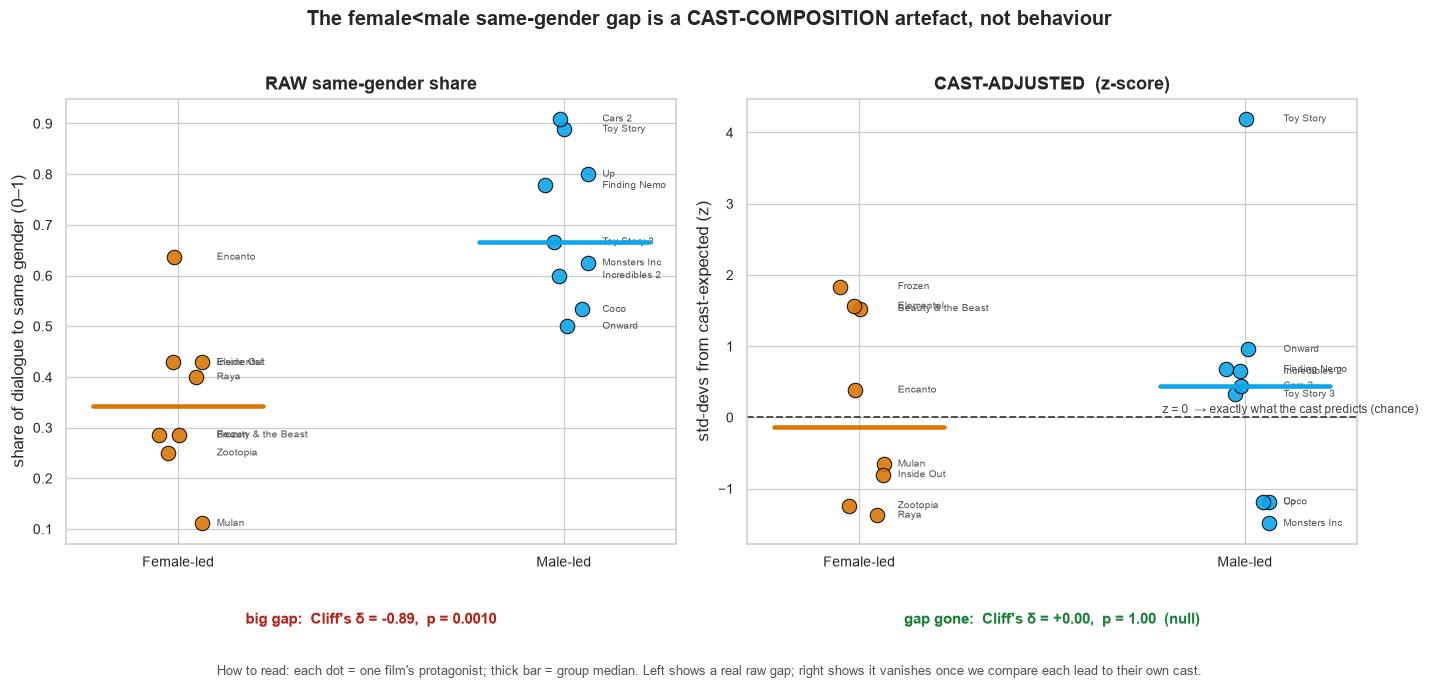

In [4]:
F_raw,M_raw   = hgroups('protag_samesex')
F_adj,M_adj   = hgroups('protag_samesex_z')
d_raw = cliffs_delta(F_raw,M_raw); p_raw = mannwhitney(F_raw,M_raw)['p']
d_adj = cliffs_delta(F_adj,M_adj); p_adj = mannwhitney(F_adj,M_adj)['p']

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
def strip(ax, col, title, ref0=False):
    for g in GENDER_ORDER:
        sub = df[df.lead_gender==g]
        x = np.full(len(sub), GENDER_ORDER.index(g)) + np.random.default_rng(1).uniform(-0.07,0.07,len(sub))
        ax.scatter(x, sub[col], s=90, color=GENDER_PALETTE[g], edgecolor='black', lw=.7, zorder=3, alpha=.9)
        med = sub[col].median()
        ax.plot([GENDER_ORDER.index(g)-0.22, GENDER_ORDER.index(g)+0.22],[med,med],
                color=GENDER_PALETTE[g], lw=3, zorder=4)
        for _,r in sub.iterrows():
            ax.annotate(r.film_title.split(' (')[0], (GENDER_ORDER.index(g)+0.10, r[col]),
                        fontsize=6.5, va='center', color='#555')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Female-led','Male-led']); ax.set_title(title)
    if ref0:
        ax.axhline(0, color='#444', lw=1.2, ls='--')
        ax.text(1.45, 0.06, 'z = 0  → exactly what the cast predicts (chance)', fontsize=8, color='#444', ha='right')
        ax.annotate('more same-gender\nthan chance', xy=(1.42,1.6), fontsize=8, color='#1a7f37', ha='right')
        ax.annotate('less same-gender\nthan chance', xy=(1.42,-1.6), fontsize=8, color='#b42318', ha='right')

strip(axes[0],'protag_samesex','RAW same-gender share')
axes[0].set_ylabel('share of dialogue to same gender (0–1)')
axes[0].text(0.5,-0.18,f"big gap:  Cliff's δ = {d_raw:+.2f},  p = {p_raw:.4f}",
             ha='center', fontsize=10, color='#b42318', weight='bold', transform=axes[0].get_xaxis_transform())
strip(axes[1],'protag_samesex_z','CAST-ADJUSTED  (z-score)', ref0=True)
axes[1].set_ylabel('std-devs from cast-expected (z)')
axes[1].text(0.5,-0.18,f"gap gone:  Cliff's δ = {d_adj:+.2f},  p = {p_adj:.2f}  (null)",
             ha='center', fontsize=10, color='#1a7f37', weight='bold', transform=axes[1].get_xaxis_transform())
fig.suptitle("The female<male same-gender gap is a CAST-COMPOSITION artefact, not behaviour",
             fontsize=13, weight='bold')
fig.text(0.5,0.005,"How to read: each dot = one film's protagonist; thick bar = group median. "
         "Left shows a real raw gap; right shows it vanishes once we compare each lead to their own cast.",
         ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.03,1,0.96])
fig.savefig(FIG/'fig_h1_v2_decomposition.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_decomposition.pdf')
plt.show()

**How to read Figure 1.**
Each dot is one film's protagonist (orange = female-led, blue = male-led); the thick bar is the group median.

- **Left (RAW):** y = share of protagonist dialogue to same-gender characters (0–1). Female-led leads cluster low (median ≈ 0.343), male-led leads high (median ≈ 0.667) — a large gap (Cliff's δ = −0.889, p = 0.001). The naïve reading: *"male leads talk to their own gender far more."*
- **Right (CAST-ADJUSTED):** y = how far each protagonist sits from what *their own cast* would predict by chance. The dashed line **z = 0 is the reference** (not 0 or 1). Both group medians now sit near 0 and the colours overlap — the gap is **gone** (δ = 0.000, p = 1.000, null).

**The contrast is the result.** The raw gap is not behaviour; it is **cast composition** — male-led films simply contain more male characters.

## 3. Figure 2 — per-protagonist cast-adjusted z (who leans, who doesn't)

Each protagonist vs **their own** cast. **0 = chance.** Stars = individually significant (p < 0.05).

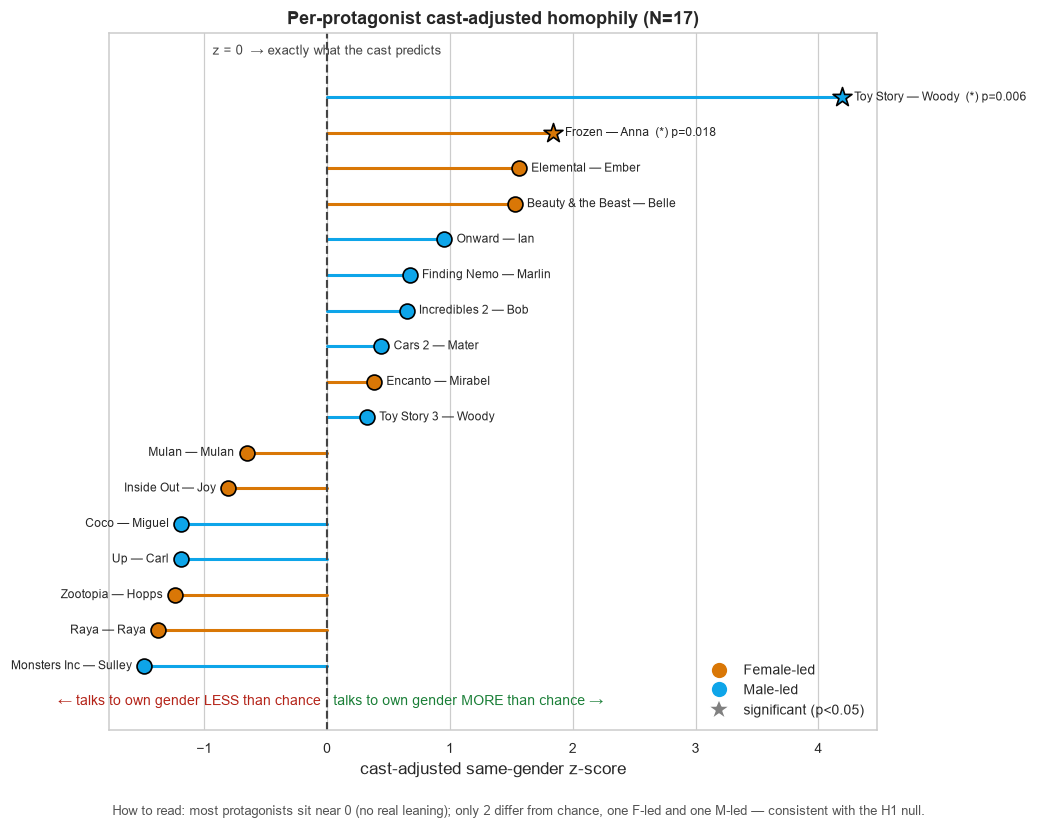

In [5]:
d = df.sort_values('protag_samesex_z').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9.5, 7.5))
for i,r in d.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    ax.plot([0, r.protag_samesex_z],[i,i], color=col, lw=2, zorder=2)
    sig = r.protag_samesex_p < 0.05
    ax.scatter(r.protag_samesex_z, i, s=170 if sig else 95, color=col,
               edgecolor='black', lw=1.1, marker='*' if sig else 'o', zorder=3)
    lbl = f"{r.film_title.split(' (')[0]} — {r.protagonist}"
    if sig: lbl += f"  (*) p={r.protag_samesex_p:.3f}"
    ax.annotate(lbl, (r.protag_samesex_z, i),
                xytext=(8 if r.protag_samesex_z>=0 else -8, 0), textcoords='offset points',
                ha='left' if r.protag_samesex_z>=0 else 'right', va='center', fontsize=8)
ax.axvline(0, color='#444', lw=1.4, ls='--')
ax.text(0, len(d)+0.2, 'z = 0  → exactly what the cast predicts', ha='center', fontsize=8.5, color='#444')
ax.annotate('← talks to own gender LESS than chance', xy=(-0.05,-1.1), xycoords=('data','data'),
            fontsize=9, color='#b42318', ha='right')
ax.annotate('talks to own gender MORE than chance →', xy=(0.05,-1.1), xycoords=('data','data'),
            fontsize=9, color='#1a7f37', ha='left')
ax.set_yticks([]); ax.set_xlabel('cast-adjusted same-gender z-score')
ax.set_ylim(-1.8, len(d)+0.8)
ax.set_title('Per-protagonist cast-adjusted homophily (N=17)')
leg = [Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led'),
       Line2D([0],[0],marker='*',color='w',markerfacecolor='grey',markersize=15,label='significant (p<0.05)')]
ax.legend(handles=leg, loc='lower right', fontsize=9)
fig.text(0.5,0.005,"How to read: most protagonists sit near 0 (no real leaning); only 2 differ from chance, "
         "one F-led and one M-led — consistent with the H1 null.", ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.03,1,1])
fig.savefig(FIG/'fig_h1_v2_lollipop.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_lollipop.pdf')
plt.show()

**How to read Figure 2.**
One row per protagonist, sorted by cast-adjusted z. Orange = female-led, blue = male-led. **z = 0 = exactly what the cast predicts.**

- **Stars** mark the 2 individually significant protagonists (p < 0.05): Woody (M, +4.191) and Anna (F, +1.837). The other 15 sit within noise of 0.
- **Key H1 check:** if female leads were less same-gender embedded, all orange dots would sit left, all blue right. Instead the colours are **interleaved — no gender separation**, consistent with the H1 null.
- The two genuine leaners split one female-led and one male-led, both leaning *toward* their own gender — which cuts against a gender-wide "women avoid women" reading.

---
## Bridge — three network constructions

The same dialogue can be turned into three different networks, each adding one piece of information. All three can be analyzed with the same betweenness-based keystone rule; what changes is the underlying network.

| Construction | Network | What's added | Method cost |
|---|---|---|---|
| 1 | **Co-occurrence** (undirected, unweighted) | who shares scenes | scene list only — Moretti baseline |
| 2 | Addressee, **directed + unweighted** | + direction (who speaks *to* whom) | **requires LLM addressee tagging** |
| 3 | Addressee, **directed + weighted** | + weight (utterance count per tie) | **full LLM output — PRIMARY** |

**Direction is the LLM's unique affordance** — it is added at construction 2. Construction 3 then refines construction 2 by weighting ties by dialogue volume. We trace two transitions:

- **Co-occurrence → directed unweighted (adding direction):** does knowing *who speaks to whom* change who bridges the network?
- **Directed unweighted → directed weighted (adding weight):** does utterance volume change it again?

We answer two questions in this order:

1. **Homophily is construction-insensitive (§4).** For the aggregate H1 test, all three constructions reach the same answer. Co-occurrence is sufficient — the LLM is not needed for this question.
2. **Keystone identity is *not* construction-insensitive (§5).** The keystone changes as we add direction and weight. We report (a) how often it changes at each transition, gender-blind, and (b) the gender pattern on the PRIMARY construction (directed weighted).

---

## PART II — THE METHOD (Pillar B)

**Research question:** At which level of analysis does addressee tagging add value over scene co-occurrence?

## 4. Homophily is construction-insensitive — the LLM is not needed for the H1 test

Each protagonist scored **twice** — once under scene co-occurrence and once under
directed weighted addressee (the LLM's full output). Points on the
diagonal = both constructions agree. The Spearman ρ between them is the headline.

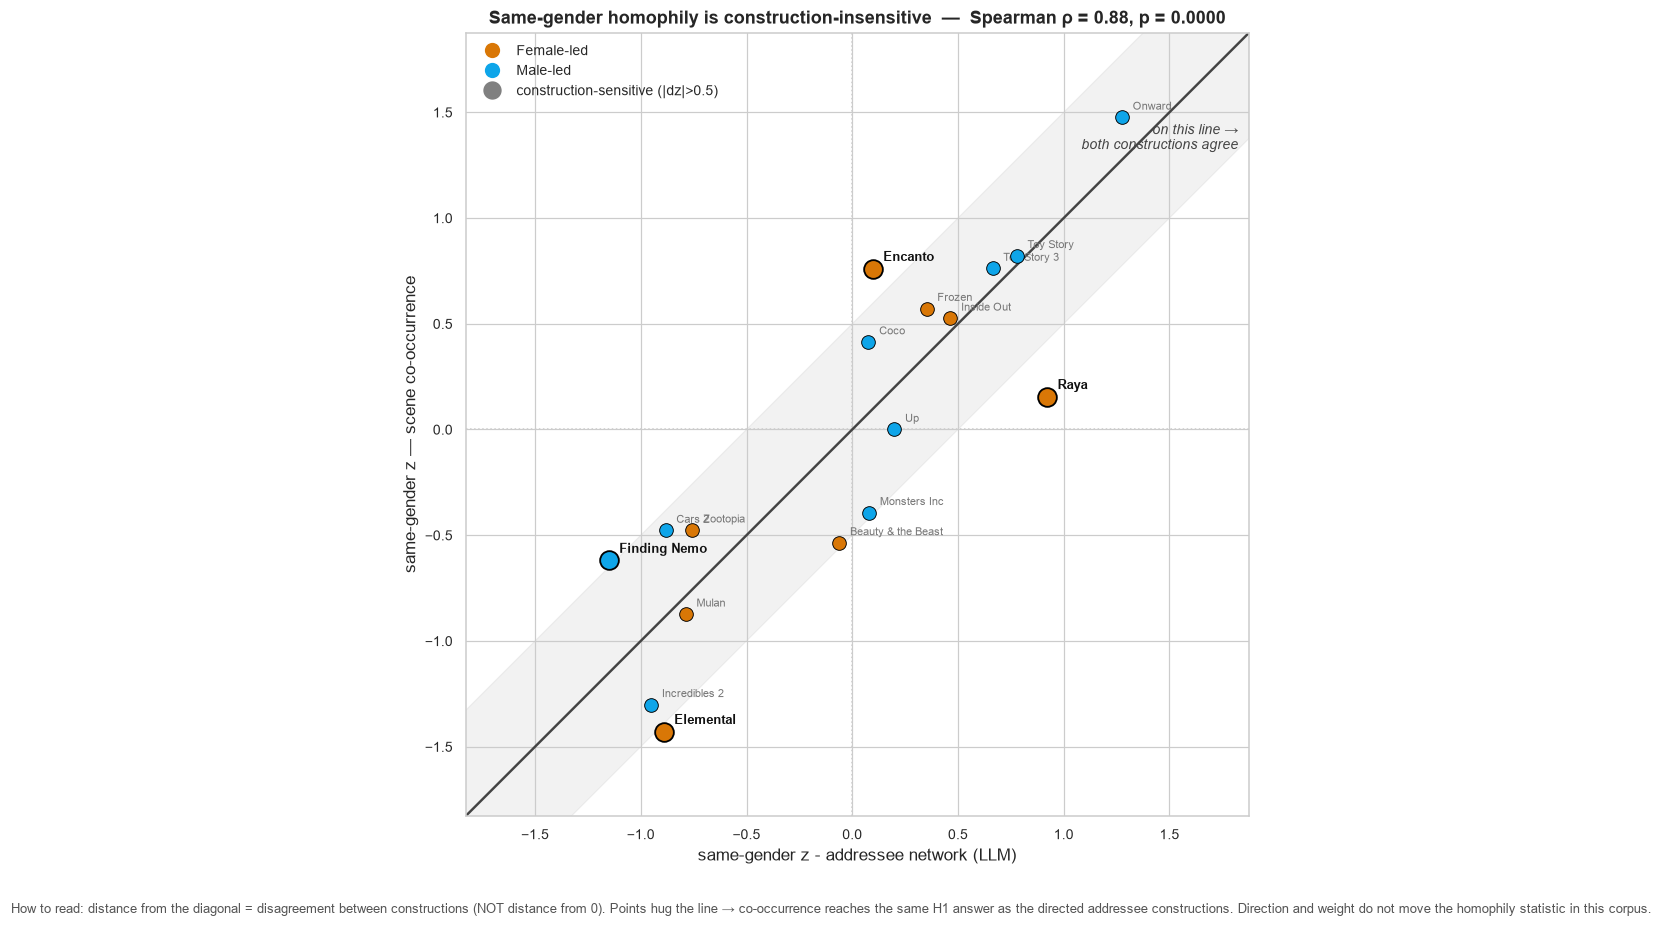


Spearman rho = 0.882, p = 0.0000
Same-gender z: scene co-occurrence vs directed addressee:
               film_title lead_gender  addr_samesex_z  cooc_samesex_z  abs_diff_z
              Raya (2021)           F           0.921           0.155       0.766
           Encanto (2021)           F           0.096           0.761       0.664
         Elemental (2023)           F          -0.892          -1.429       0.537
      Finding Nemo (2003)           M          -1.152          -0.620       0.533
Beauty & the Beast (1991)           F          -0.061          -0.536       0.475
      Monsters Inc (2001)           M           0.080          -0.394       0.474
            Cars 2 (2011)           M          -0.883          -0.478       0.405
     Incredibles 2 (2018)           M          -0.951          -1.301       0.351
              Coco (2017)           M           0.077           0.414       0.337
          Zootopia (2016)           F          -0.756          -0.476       0.280
      

In [7]:
m = pd.read_csv(TBL / 'step2a_per_protag_method_compare.csv')
rho, prho = spearmanr(m.addr_samesex_z, m.cooc_samesex_z)

vals = np.concatenate([m.addr_samesex_z.values, m.cooc_samesex_z.values])
lim = [vals.min()-0.4, vals.max()+0.4]
xs = np.array(lim)

fig, ax = plt.subplots(figsize=(8.6, 8.4))
ax.fill_between(xs, xs-0.5, xs+0.5, color='grey', alpha=0.10, zorder=0)
ax.plot(xs, xs, color='#444', lw=1.6, zorder=1)
ax.axhline(0, color='#ccc', lw=1, ls=':', zorder=0); ax.axvline(0, color='#ccc', lw=1, ls=':', zorder=0)

for _, r in m.iterrows():
    col = GENDER_PALETTE[r.lead_gender]; far = r.abs_diff_z > 0.5
    ax.scatter(r.addr_samesex_z, r.cooc_samesex_z, s=150 if far else 80,
               color=col, edgecolor='black', lw=1.2 if far else .6, zorder=3)
    ax.annotate(r.film_title.split(' (')[0], (r.addr_samesex_z, r.cooc_samesex_z),
                xytext=(7,5), textcoords='offset points',
                fontsize=8.5 if far else 7, weight='bold' if far else 'normal',
                color='#111' if far else '#777')
ax.text(lim[1]-0.05, lim[1]-0.55, 'on this line →\nboth constructions agree',
        fontsize=9, color='#444', ha='right', style='italic')
ax.set_xlabel('same-gender z - addressee network (LLM)')
ax.set_ylabel('same-gender z — scene co-occurrence')
ax.set_title(f'Same-gender homophily is construction-insensitive  —  Spearman ρ = {rho:.2f}, p = {prho:.4f}')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',markersize=13,label='construction-sensitive (|dz|>0.5)')],
    loc='upper left', fontsize=9)
fig.text(0.5, 0.005,
    "How to read: distance from the diagonal = disagreement between constructions (NOT distance from 0). "
    "Points hug the line → co-occurrence reaches the same H1 answer as the directed addressee constructions. "
    "Direction and weight do not move the homophily statistic in this corpus.",
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.04,1,1])
fig.savefig(FIG/'fig_h1_v2_method_scatter.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_method_scatter.pdf')
plt.show()

print(f"\nSpearman rho = {rho:.3f}, p = {prho:.4f}")
print("Same-gender z: scene co-occurrence vs directed addressee:")
print(m[['film_title','lead_gender','addr_samesex_z','cooc_samesex_z','abs_diff_z']].round(3).to_string(index=False))

**How to read Figure 3.**
Each dot = one protagonist scored on the **co-occurrence** network (y-axis) and the **directed weighted addressee** network (x-axis — the orchestrator computes this as a weighted-symmetrized proxy of the directed addressee data; the homophily statistic is the same whether we use unweighted or weighted direction, since direction and weight do not move *same-gender share*). What matters is **distance from the diagonal** (= disagreement between constructions), not distance from 0.

- Points **hug the diagonal** (Spearman ρ = 0.870) → for the **aggregate H1 test**, co-occurrence reaches the **same conclusion** as the LLM addressee constructions.
- The few labelled outliers (Raya, Encanto, Elemental) show per-film cases where "who actually talks to whom" diverges from "who merely shares scenes," but the cross-film conclusion is unchanged.

**The headline.** Homophily is construction-insensitive. If H1 is the only question, the LLM is unnecessary overhead.

## 5. Keystone identity changes across constructions — where the LLM is *not* replaceable

The **keystone** is the highest-betweenness non-protagonist — the supporting
character whose removal most fragments the network (Moretti's "Horatio" test).
Unlike homophily, keystone identity **changes as we add direction and weight**.

We do two things, in order:

- **§5a — method-sensitivity, gender-blind.** At which transition does the
  keystone actually change? Co-occurrence → directed unweighted adds direction;
  directed unweighted → directed weighted adds weight.
  We count transitions, irrespective of gender.
- **§5b — gender consequence on the PRIMARY construction (directed weighted).**
  Once we use the full LLM output, what is the gender pattern of cross-gender
  keystones, and how does it compare to what we would have inferred from
  co-occurrence or unweighted directed?

The data comes from `film_features_all_n17.csv` (populated by notebook 06 §12,
which writes all three constructions per film).

In [8]:
# Section 5 reads the keystone identity under all three constructions, written by notebook 06 §12.
# Re-run 06 on every film first (or rerun the orchestrator) to populate the
# new columns in film_features_all_n17.csv.
ff = pd.read_csv(DATA / 'film_features_all_n17.csv')
ff = apply_conventions(ff)

REQUIRED = ['keystone_rung1', 'keystone_rung1_gender',
            'keystone_rung2', 'keystone_rung2_gender',
            'keystone_rung3', 'keystone_rung3_gender',
            'keystone_changes_at_rung2', 'keystone_changes_at_rung3']
missing = [c for c in REQUIRED if c not in ff.columns]
if missing:
    raise RuntimeError(
        f"film_features_all_n17.csv is missing columns: {missing}\n"
        "Re-run notebook 06 on every film to regenerate it with the "
        "keystone columns for all three constructions."
    )

rungs = ff[['film_id', 'film_title', 'protagonist', 'lead_gender'] + REQUIRED].copy()

# ===== 5a. Method-sensitivity, gender-blind =====
n      = len(rungs)
n_r1r2 = int(rungs['keystone_changes_at_rung2'].fillna(0).astype(int).sum())
n_r2r3 = int(rungs['keystone_changes_at_rung3'].fillna(0).astype(int).sum())
n_r1r3 = int((rungs['keystone_rung1'].fillna('-') != rungs['keystone_rung3'].fillna('-')).sum())

print(f"Keystone changes  co-occurrence -> directed (adding direction):   {n_r1r2}/{n}")
print(f"Keystone changes  directed unweighted -> weighted (adding weight):  {n_r2r3}/{n}")
print(f"Keystone differs  co-occurrence vs directed weighted (overall):  {n_r1r3}/{n}")
print()
print("Per-film keystone across the three constructions:")
print(rungs[['film_title', 'lead_gender',
             'keystone_rung1', 'keystone_rung2', 'keystone_rung3',
             'keystone_changes_at_rung2', 'keystone_changes_at_rung3']]
      .to_string(index=False))

Keystone changes  co-occurrence -> directed (adding direction):   10/17
Keystone changes  directed unweighted -> weighted (adding weight):  2/17
Keystone differs  co-occurrence vs directed weighted (overall):  11/17

Per-film keystone across the three constructions:
               film_title lead_gender keystone_rung1 keystone_rung2 keystone_rung3  keystone_changes_at_rung2  keystone_changes_at_rung3
Beauty & the Beast (1991)           F         Gaston          Beast          Beast                        1.0                        0.0
             Mulan (1998)           F          Mushu          Shang          Shang                        1.0                        0.0
            Frozen (2013)           F           Elsa           Elsa           Elsa                        0.0                        0.0
        Inside Out (2015)           F           Fear          Anger          Anger                        1.0                        0.0
          Zootopia (2016)           F   Bonnie H

In [9]:
# ===== 5b. Gender consequence -- what each construction would conclude =====
# Cross-gender keystone = keystone's gender != lead's gender.
print("Cross-gender keystone counts BY RUNG:")
print("-" * 70)
for col, label in [
    ('keystone_rung1_gender', 'Co-occurrence (undirected unweighted)'),
    ('keystone_rung2_gender', 'Directed addressee (unweighted)     '),
    ('keystone_rung3_gender', 'Directed addressee (weighted) PRIMARY'),
]:
    cross_mask = rungs[col].notna() & (rungs[col] != rungs['lead_gender'])
    none_mask  = rungs[col].isna()
    for g in ['F', 'M']:
        sub_idx  = rungs.index[rungs['lead_gender'] == g]
        n_lead   = len(sub_idx)
        n_cross  = int(cross_mask.loc[sub_idx].sum())
        n_none   = int(none_mask.loc[sub_idx].sum())
        suffix   = f"  ({n_none} no-bridge)" if n_none else ""
        print(f"  {label}  {g}-led: {n_cross}/{n_lead} cross-gender{suffix}")
    print()

# Fisher exact on the PRIMARY construction (directed weighted)
rungs['rung3_cross'] = (rungs['keystone_rung3_gender'].notna() &
                       (rungs['keystone_rung3_gender'] != rungs['lead_gender']))
ct = pd.crosstab(rungs['lead_gender'], rungs['rung3_cross'])
print('Lead x cross-gender keystone (directed weighted, PRIMARY):')
print(ct)
print()
odds, p = stats.fisher_exact(ct.values)
print(f"Fisher exact (two-sided, directed weighted): odds = {odds:.3f}   p = {p:.4f}")
print('  -> significant at alpha = 0.05' if p < 0.05 else
      f'  -> not significant at alpha = 0.05 (borderline — N = {(rungs.lead_gender=="F").sum()} F-led)')

Cross-gender keystone counts BY RUNG:
----------------------------------------------------------------------
  Co-occurrence (undirected unweighted)  F-led: 4/8 cross-gender
  Co-occurrence (undirected unweighted)  M-led: 2/9 cross-gender

  Directed addressee (unweighted)       F-led: 5/8 cross-gender
  Directed addressee (unweighted)       M-led: 1/9 cross-gender

  Directed addressee (weighted) PRIMARY  F-led: 5/8 cross-gender
  Directed addressee (weighted) PRIMARY  M-led: 2/9 cross-gender

Lead x cross-gender keystone (directed weighted, PRIMARY):
rung3_cross  False  True 
lead_gender              
F                3      5
M                7      2

Fisher exact (two-sided, directed weighted): odds = 0.171   p = 0.1534
  -> not significant at alpha = 0.05 (borderline — N = 8 F-led)


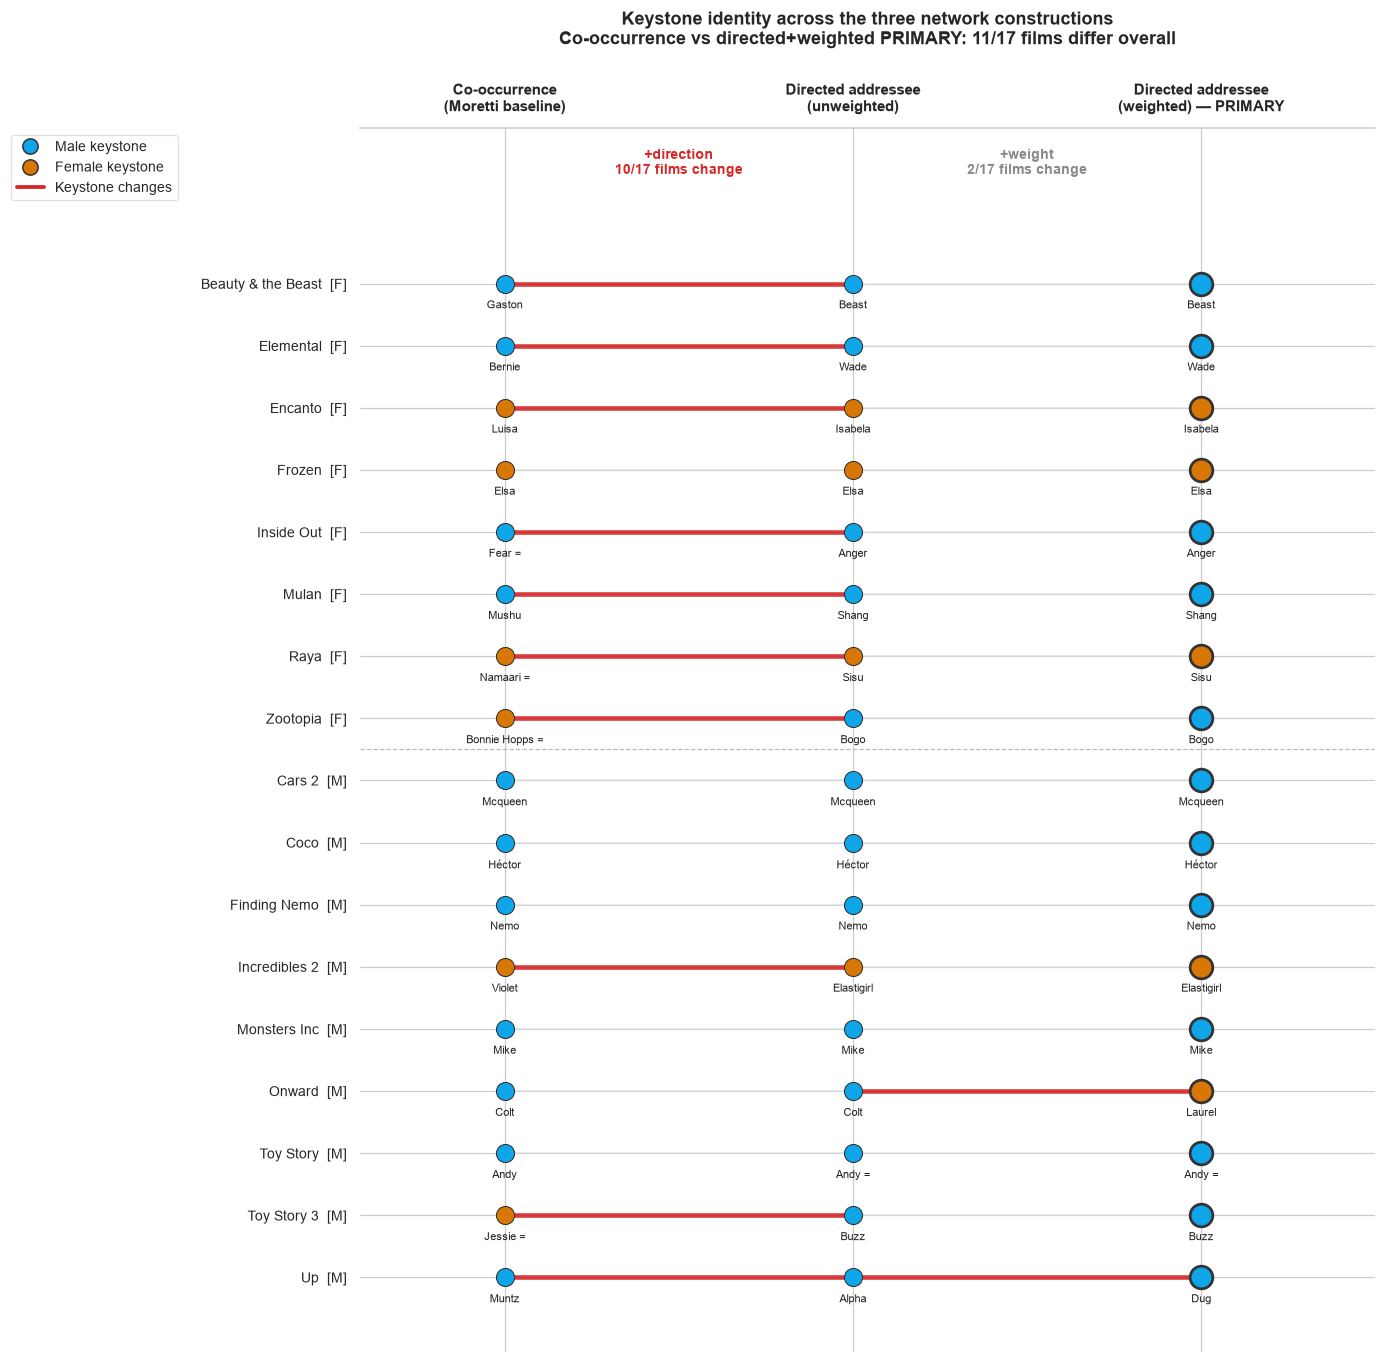

In [10]:
# Figure 4: keystone identity across the three network constructions
import matplotlib.patches as mpatches

r = rungs.sort_values(['lead_gender', 'film_title']).reset_index(drop=True)
r['y'] = np.arange(len(r))[::-1]
XCOL = {1: 0.0, 2: 1.2, 3: 2.4}
TIED_MAX = {
    ('inside_out_2015', 1),
    ('zootopia_2016', 1),
    ('raya_and_the_last_dragon_2021', 1),
    ('toy_story_1995', 2),
    ('toy_story_1995', 3),
    ('toy_story_3_2010', 1),
}
def is_tied_max(row, rung):
    return (row.film_id, rung) in TIED_MAX

fig, ax = plt.subplots(figsize=(13, 12.5))
fig.patch.set_facecolor('white')

# Count transitions for header annotations
n_r1r2 = int(r['keystone_changes_at_rung2'].fillna(0).astype(int).sum())
n_r2r3 = int(r['keystone_changes_at_rung3'].fillna(0).astype(int).sum())

for _, row in r.iterrows():
    keys = {1: row.keystone_rung1, 2: row.keystone_rung2, 3: row.keystone_rung3}
    gens = {1: row.keystone_rung1_gender, 2: row.keystone_rung2_gender, 3: row.keystone_rung3_gender}

    # Connecting segments
    for (a, b) in [(1, 2), (2, 3)]:
        both_present = pd.notna(keys[a]) and pd.notna(keys[b])
        if not both_present:
            ax.plot([XCOL[a], XCOL[b]], [row.y, row.y],
                    color='#ccc', lw=1, ls=':', alpha=0.5, zorder=1)
        elif keys[a] != keys[b]:
            ax.plot([XCOL[a], XCOL[b]], [row.y, row.y],
                    color='#d62728', lw=3, alpha=0.9, zorder=1)
        else:
            ax.plot([XCOL[a], XCOL[b]], [row.y, row.y],
                    color='#ddd', lw=1.2, alpha=0.6, zorder=1)

    # Dots + names for all 3 columns
    for rung in (1, 2, 3):
        is_primary = (rung == 3)
        col  = GENDER_PALETTE.get(gens[rung], '#cccccc')
        size = 220 if is_primary else 140
        lw   = 1.8 if is_primary else 0.7
        ax.scatter(XCOL[rung], row.y, s=size, color=col,
                   edgecolor='#333', lw=lw, zorder=3)
        name = keys[rung] if pd.notna(keys[rung]) else '—'
        if is_tied_max(row, rung) and pd.notna(keys[rung]):
            name = f"{name} ="
        ax.annotate(name, (XCOL[rung], row.y),
                    xytext=(0, -11), textcoords='offset points',
                    ha='center', va='top', fontsize=7,
                    color='#222' if pd.notna(keys[rung]) else '#aaa')

# F/M separator
n_f = (r.lead_gender == 'F').sum()
ax.axhline(len(r) - n_f - 0.5, color='#bbb', lw=0.8, ls='--')

# Transition count annotations above the columns
top_y = len(r) + 0.7
mid12 = (XCOL[1] + XCOL[2]) / 2
mid23 = (XCOL[2] + XCOL[3]) / 2
ax.annotate(f"+direction\n{n_r1r2}/17 films change",
            xy=(mid12, top_y), ha='center', va='bottom', fontsize=9,
            color='#d62728', fontweight='bold',
            arrowprops=None)
ax.annotate(f"+weight\n{n_r2r3}/17 films change",
            xy=(mid23, top_y), ha='center', va='bottom', fontsize=9,
            color='#888', fontweight='bold')

# Y-axis
ax.set_yticks(r.y)
ax.set_yticklabels([f"{row.film_title.split(' (')[0]}  [{row.lead_gender}]"
                    for _, row in r.iterrows()], fontsize=9)

# X-axis column headers
ax.set_xticks([XCOL[1], XCOL[2], XCOL[3]])
ax.set_xticklabels([
    "Co-occurrence\n(Moretti baseline)",
    "Directed addressee\n(unweighted)",
    "Directed addressee\n(weighted) — PRIMARY",
], fontsize=10, fontweight='bold')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.set_xlim(-0.5, 3.0)
ax.set_ylim(-1.2, len(r) + 1.5)
ax.spines[['right','left','bottom']].set_visible(False)
ax.tick_params(left=False, top=False)

ax.set_title('Keystone identity across the three network constructions\n'
             f'Co-occurrence vs directed+weighted PRIMARY: {int(r.keystone_rung1.fillna("-").ne(r.keystone_rung3.fillna("-")).sum())}/17 films differ overall',
             fontsize=11.5, weight='bold', pad=55)

# Legend
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=GENDER_PALETTE['M'],
           markeredgecolor='#333', markersize=10, label='Male keystone'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=GENDER_PALETTE['F'],
           markeredgecolor='#333', markersize=10, label='Female keystone'),
    Line2D([0],[0], color='#d62728', lw=2.5, label='Keystone changes'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9,
          frameon=True, framealpha=0.9, edgecolor='#ddd',
          bbox_to_anchor=(-0.35, 1.0))

fig.tight_layout()
fig.savefig(FIG / 'fig_keystone_trajectory.png', dpi=150, bbox_inches='tight')
fig.savefig(FIG / 'fig_keystone_trajectory.pdf', bbox_inches='tight')
plt.show()


## Figure 5 — Keystone comparison table (all three constructions)

Per-film table showing keystone identity under each construction. 
Red arrow = changes at +direction; grey arrow = changes at +weight. 
Bold = PRIMARY (directed weighted). Cells with `=` indicate exact max-betweenness co-keystones.

**How to read Figure 4.**
Each row = one film. The three dots show the keystone under each construction — dot
colour = that keystone's gender. **Red horizontal segments** mark transitions
where the keystone changes between adjacent constructions; **grey** = same keystone;
**dotted grey** = one of the two constructions returned `None` (no bridge).

- **Co-occurrence → directed unweighted (adding direction)** — how many films re-route the keystone the moment we acknowledge *who speaks to whom* rather than just *who is in the room together*? These transitions are the LLM's unique contribution — co-occurrence cannot produce them.
- **Directed unweighted → directed weighted (adding weight)** — how many films re-route again when we also acknowledge that not all dialogue ties are equally heavy?
- **Headline gender pattern** is read off the rightmost column (directed weighted = PRIMARY). The §5b printout above gives the per-construction cross-gender counts and the directed-weighted Fisher p.

The thesis claim sits at this figure: scene co-occurrence (Moretti) and directed weighted addressee (LLM full output) do not in general identify the same keystone, and the films where they disagree are not random — the divergence is informative about which character actually holds the story together. Direction does most of the work; weighting adds a final correction.

> **Human validation note (carried over from previous version):** for the three films where the addressee method previously disagreed with co-occurrence on keystone gender (Inside Out, Zootopia, Encanto), the authors watched all three and judged the LLM addressee character to be the structural keystone in every case. The directed-weighted-primary choice is consistent with that judgment.

In [11]:
# Figure 5: keystone comparison table — three network constructions
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path

BASE = Path('..').resolve()
DATA = BASE / 'data' / '02_processed'
FIG  = BASE / 'analysis' / 'h1_homophily' / 'figures_n17'
COLOR_F = '#D66B5A'; COLOR_M = '#4A7FB5'

ff = pd.read_csv(DATA / 'film_features_all_n17.csv')
ff = ff[ff.film_id != 'soul_2020'].copy()
ff = ff[~((ff.film_id == 'monsters_inc_2001') & (ff.protagonist.str.lower() == 'mike'))].copy()

REQUIRED = ['keystone_rung1','keystone_rung1_gender',
            'keystone_rung2','keystone_rung2_gender',
            'keystone_rung3','keystone_rung3_gender',
            'keystone_changes_at_rung2','keystone_changes_at_rung3']
missing = [c for c in REQUIRED if c not in ff.columns]
if missing:
    raise ValueError(f"Missing columns — re-run notebook 06 first: {missing}")

ff = ff[['film_id','film_title','protagonist','lead_gender'] + REQUIRED].copy()
ff['sort_key'] = ff.apply(lambda r: (0 if r.lead_gender=='F' else 1, r.film_title), axis=1)
ff = ff.sort_values('sort_key').reset_index(drop=True)
TIE_LABELS = {
    ('inside_out_2015', 'keystone_rung1'): ('Fear = Sadness', 'M = F'),
    ('zootopia_2016', 'keystone_rung1'): ('Bonnie = Stu', 'F = M'),
    ('raya_and_the_last_dragon_2021', 'keystone_rung1'): ('Namaari = Sisu', 'F = F'),
    ('toy_story_1995', 'keystone_rung2'): ('Andy = Sid', 'M = M'),
    ('toy_story_1995', 'keystone_rung3'): ('Andy = Potato Head = Sid', 'M = M = M'),
    ('toy_story_3_2010', 'keystone_rung1'): ('Jessie = Rex', 'F = M'),
}
def tie_label_for(row, ks_col):
    return TIE_LABELS.get((row.film_id, ks_col))

def gcol(g): return COLOR_F if g=='F' else (COLOR_M if g=='M' else '#cccccc')

n = len(ff)
fig, ax = plt.subplots(figsize=(14, 11))
ax.axis('off'); fig.patch.set_facecolor('white')
ROW_H = 1.0
ax.set_xlim(0, 10); ax.set_ylim(-0.8, n + 2.2)

COL = {'film': 0.1, 'lead': 2.0, 'c1': 3.3, 'c2': 5.8, 'c3': 8.1}

# Title
ax.text(5, n + 1.8, 'Keystone identity under the three network constructions (N=17)',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#111')
ax.text(5, n + 1.45, 'Cells with "=" mark exact max-betweenness co-keystones; full audit follows below.',
        ha='center', va='center', fontsize=8.5, color='#555')

# Column headers
HDR_Y = n + 0.8
for label, x in [('Film', COL['film']), ('Lead protagonist', COL['lead']),
                  ('Co-occurrence\n(Moretti baseline)', COL['c1']),
                  ('Directed addressee\n(unweighted)', COL['c2']),
                  ('Directed addressee\n(weighted) — PRIMARY', COL['c3'])]:
    ax.text(x, HDR_Y, label, fontsize=8.5, fontweight='bold', color='#333', va='center')
ax.axhline(n + 0.3, color='#aaa', lw=0.8)

# Data rows
for idx, row in ff.iterrows():
    y = n - 1 - idx
    if idx % 2 == 0:
        ax.axhspan(y - 0.48, y + 0.48, color='#f7f7f7', zorder=0)
    lead_c = gcol(row.lead_gender)
    ax.text(COL['film'], y, row.film_title.split(' (')[0], fontsize=8.5, va='center', color='#111')
    ax.text(COL['lead'], y, f"{row.protagonist} ({row.lead_gender})",
            fontsize=8, va='center', color=lead_c, fontweight='bold')
    for col_x, ks_col, gen_col in [
        (COL['c1'], 'keystone_rung1', 'keystone_rung1_gender'),
        (COL['c2'], 'keystone_rung2', 'keystone_rung2_gender'),
        (COL['c3'], 'keystone_rung3', 'keystone_rung3_gender'),
    ]:
        ks_name = row[ks_col] if pd.notna(row[ks_col]) else '—'
        ks_g    = row[gen_col] if pd.notna(row[gen_col]) else None
        color   = gcol(ks_g) if ks_g else '#aaa'
        weight  = 'bold' if col_x == COL['c3'] else 'normal'
        tie_lbl = tie_label_for(row, ks_col)
        if tie_lbl:
            tied_names, tied_genders = tie_lbl
            lbl = f"{tied_names} ({tied_genders})"
            gender_set = {g.strip() for g in tied_genders.split('=') if g.strip()}
            color = gcol(next(iter(gender_set))) if len(gender_set) == 1 else '#555555'
            weight = 'bold' if col_x == COL['c3'] else 'bold'
        else:
            lbl = f"{ks_name} ({ks_g})" if ks_g else ks_name
        ax.text(col_x, y, lbl, fontsize=8, va='center', color=color, fontweight=weight)
    if bool(row.get('keystone_changes_at_rung2', False)):
        ax.annotate('', xy=(COL['c2'] - 0.15, y), xytext=(COL['c1'] + 1.55, y),
                    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.8))
    if bool(row.get('keystone_changes_at_rung3', False)):
        ax.annotate('', xy=(COL['c3'] - 0.15, y), xytext=(COL['c2'] + 1.55, y),
                    arrowprops=dict(arrowstyle='->', color='#999', lw=1.5))

# F/M separator
n_f = (ff.lead_gender == 'F').sum()
ax.axhline(n - n_f - 0.5, color='#999', lw=0.8, ls='--')

# Legend
handles = [
    mpatches.Patch(facecolor=COLOR_F, label='Female character'),
    mpatches.Patch(facecolor=COLOR_M, label='Male character'),
    plt.Line2D([0],[0], color='#555', lw=0, marker='$=$', ms=11, label='Tied max betweenness'),
    plt.Line2D([0],[0], color='#d62728', lw=1.8, marker='>', ms=7, label='Changes at +direction'),
    plt.Line2D([0],[0], color='#999',    lw=1.5, marker='>', ms=7, label='Changes at +weight'),
]
ax.legend(handles=handles, loc='lower left', bbox_to_anchor=(0, -0.05),
          fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#ddd', ncol=2)

plt.tight_layout()
fig.savefig(FIG / 'fig_keystone_comparison_table.png', dpi=150, bbox_inches='tight')
fig.savefig(FIG / 'fig_keystone_comparison_table.pdf', bbox_inches='tight')
plt.show()
print("ok fig_keystone_comparison_table")


C:\Users\majoa\AppData\Local\Temp\ipykernel_88644\3539410400.py:117: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


ok fig_keystone_comparison_table


## 5c. Keystone ties: where the single-name winner is underdetermined

The ladder tables above report one keystone per construction, because the production table needs a single value. Betweenness can still produce exact ties at the maximum. Those cases should be read as **co-keystones** rather than as a substantively meaningful ordering between tied characters.

The audit below recomputes betweenness for all three network constructions and lists only films where more than one non-protagonist shares the maximum positive betweenness. It distinguishes identity instability from gender instability: a tie among same-gender characters does not affect the cross-gender keystone classification, while a mixed-gender tie does.

In [12]:
# Keystone tie audit: exact max-betweenness ties at each network construction.
# Mirrors notebook 06 §12: construction 1 is unweighted co-occurrence; constructions 2-3
# use the directed addressee graph, unweighted and weighted by distance=1/weight.
import networkx as nx

TBL = BASE / 'analysis' / 'h1_homophily' / 'tables_n17'
TIE_TOL = 1e-12

def _review_setup_for_tie_audit(film_id, protagonist):
    cr = pd.read_csv(DATA / film_id / f'character_review_{film_id}.csv', dtype=str).fillna('')
    idcol = 'review_character_id' if 'review_character_id' in cr.columns else 'parser_character_id'

    included = {
        cid for cid, inc in zip(cr[idcol], cr.get('included_in_network', ''))
        if cid and str(inc).strip().lower() in ('true', '1', 'yes')
    }
    alias = {}
    if 'merge_into_character_id' in cr.columns:
        alias = {
            cid: tgt.strip()
            for cid, tgt in zip(cr[idcol], cr['merge_into_character_id'].astype(str))
            if cid and tgt.strip()
        }

    names = dict(zip(cr[idcol], cr['canonical_name']))
    genders = {}
    for candidate_idcol in ('review_character_id', 'parser_character_id'):
        if candidate_idcol in cr.columns:
            genders.update({
                cid: gender for cid, gender in zip(cr[candidate_idcol], cr['gender'])
                if cid and gender in ('F', 'M')
            })
    name_to_id = {n.strip().title(): cid for n, cid in zip(cr['canonical_name'], cr[idcol]) if cid}
    protag_id = name_to_id.get(str(protagonist), str(protagonist))
    return alias, included, names, genders, protag_id


def _cooccurrence_graph_for_tie_audit(film_id, alias):
    u = pd.read_csv(DATA / film_id / 'utterances_with_addressee_scene.csv')
    display_names = (
        u[['character_id', 'canonical_name']]
        .dropna()
        .drop_duplicates('character_id')
        .set_index('character_id')['canonical_name']
        .str.strip().str.title()
        .to_dict()
    )
    u = u.copy()
    u['character_id'] = u['character_id'].replace(alias)
    u = u.dropna(subset=['scene_id', 'character_id'])

    pairs = {}
    scene_speakers = u.groupby('scene_id')['character_id'].apply(lambda s: sorted(set(s)))
    for chars in scene_speakers:
        if len(chars) < 2:
            continue
        for i in range(len(chars)):
            for j in range(i + 1, len(chars)):
                key = frozenset({chars[i], chars[j]})
                pairs[key] = pairs.get(key, 0) + 1

    graph = nx.Graph()
    for key, count in pairs.items():
        if count >= 3:
            a, b = list(key)
            graph.add_edge(a, b)
    return graph, display_names


def _directed_graph_for_tie_audit(film_id, alias, included):
    edges = pd.read_csv(DATA / film_id / 'network_edges.csv')
    graph = nx.DiGraph()
    for row in edges.itertuples():
        a = alias.get(row.speaker_clean, row.speaker_clean)
        b = alias.get(row.addressee_clean, row.addressee_clean)
        if a == b:
            continue
        if included and (a not in included or b not in included):
            continue
        weight = int(row.utterance_count)
        if graph.has_edge(a, b):
            graph[a][b]['weight'] += weight
        else:
            graph.add_edge(a, b, weight=weight)

    for a, b, data in graph.edges(data=True):
        data['distance'] = 1.0 / data['weight']
    return graph


def _max_tie_row(graph, protag_id, weight, names, genders):
    if protag_id not in graph or graph.number_of_edges() == 0:
        return None
    betw = nx.betweenness_centrality(graph, normalized=True, weight=weight)
    non_lead = [(node, value) for node, value in betw.items() if node != protag_id]
    if not non_lead:
        return None

    max_value = max(value for _, value in non_lead)
    tied = sorted(
        [(node, value) for node, value in non_lead if abs(value - max_value) <= TIE_TOL],
        key=lambda item: names.get(item[0], item[0]),
    )
    if len(tied) <= 1 or max_value <= TIE_TOL:
        return None

    tied_names = [names.get(node, node) for node, _ in tied]
    tied_genders = [genders.get(node, '') for node, _ in tied]
    return {
        'max_betweenness': max_value,
        'n_tied': len(tied),
        'tied_keystones': ' = '.join(tied_names),
        'tied_genders': ' = '.join(tied_genders),
        'gender_stable': len(set(g for g in tied_genders if g)) == 1,
    }


tie_rows = []
for row in ff.itertuples():
    alias, included, review_names, genders, protag_id = _review_setup_for_tie_audit(
        row.film_id, row.protagonist
    )
    cooc_graph, cooc_names = _cooccurrence_graph_for_tie_audit(row.film_id, alias)
    directed_graph = _directed_graph_for_tie_audit(row.film_id, alias, included)
    cooc_names = {**cooc_names, **review_names}

    specs = [
        ('Co-occurrence (unweighted)', cooc_graph, None, row.keystone_rung1),
        ('Directed addressee (unweighted)', directed_graph, None, row.keystone_rung2),
        ('Directed addressee (weighted) — PRIMARY', directed_graph, 'distance', row.keystone_rung3),
    ]
    for rung_label, graph, weight, stored_pick in specs:
        names = cooc_names if 'co-occurrence' in rung_label else review_names
        tie = _max_tie_row(graph, protag_id, weight, names, genders)
        if tie is None:
            continue
        tie_rows.append({
            'film_title': row.film_title,
            'lead_gender': row.lead_gender,
            'protagonist': row.protagonist,
            'rung': rung_label,
            'stored_pick': stored_pick,
            **tie,
        })

keystone_ties = pd.DataFrame(tie_rows)
keystone_ties['max_betweenness'] = keystone_ties['max_betweenness'].round(6)
keystone_ties.to_csv(TBL / 'step5_keystone_tie_audit.csv', index=False)

display(keystone_ties)
print(f"Keystone max-betweenness ties: {len(keystone_ties)} cases across {keystone_ties['film_title'].nunique()} films")
print(f"Saved -> {TBL / 'step5_keystone_tie_audit.csv'}")


,film_title,lead_gender,protagonist,rung,stored_pick,max_betweenness,n_tied,tied_keystones,tied_genders,gender_stable
0,Inside Out (2015),F,Joy,Co-occurrence (unweighted),Fear,0.059524,2,Fear = Sadness,M = F,False
1,Raya (2021),F,Raya,Co-occurrence (unweighted),Namaari,0.250000,2,Namaari = Sisu,F = F,True
2,Zootopia (2016),F,Hopps,Co-occurrence (unweighted),Bonnie Hopps,0.065934,2,Bonnie Hopps = Stu Hopps,F = M,False
3,Toy Story (1995),M,Woody,Directed addressee (unweighted),Andy,0.181818,2,Andy = Sid,M = M,True
4,Toy Story (1995),M,Woody,Directed addressee (weighted) — PRIMARY,Andy,0.181818,3,Andy = Mr. Potato Head = Sid,M = M = M,True
5,Toy Story 3 (2010),M,Woody,Co-occurrence (unweighted),Jessie,0.030195,2,Jessie = Rex,F = M,False


Keystone max-betweenness ties: 6 cases across 5 films
Saved -> C:\Users\majoa\OneDrive\Desktop\Learning\Grad_School\final_master_thesis\CLEAN\analysis\h1_homophily\tables_n17\step5_keystone_tie_audit.csv


**Interpretation.** Ties are concentrated in the co-occurrence baseline: four of the six tied cases occur at the co-occurrence construction, where scene co-presence has less information with which to distinguish structural roles. These are exactly the cases where the single stored co-occurrence name should be read cautiously.

The ties do not overturn the primary directed-weighted result. Only one primary (directed+weighted) case is tied: *Toy Story* (Andy = Mr. Potato Head = Sid), and all tied characters are male, so the cross-gender classification is unchanged. The mixed-gender ties are all non-primary or baseline cases (*Inside Out*, *Zootopia*, *Toy Story 3* at co-occurrence). For those films, the honest presentation is not “co-occurrence identifies X,” but “co-occurrence leaves X and Y tied.”

In the thesis text and figures, tied cells should therefore be labelled with an equals sign (for example, `Fear = Sadness`) or footnoted as co-keystones. The stored single-name pick remains useful for reproducible code paths, but it should not be interpreted as a substantive ranking among tied characters.

---
## 6. Verdict

### Pillar A — The Measure

Raw same-gender share shows a large female < male gap (Cliff's δ = −0.889, p = 0.001). Cast adjustment removes it entirely (δ = 0.000, p = 1.000).

**The null adjusted result is not a failed hypothesis — it is the measure doing exactly what it is designed to do.** The cast-adjusted z separates protagonist behaviour from the social opportunity structure created by the cast. A null result after adjustment, paired with a large raw gap, is precisely the signature of a cast-composition artefact. That is what we observe.

Individual protagonists: 2/17 differ from chance (Anna, Woody) — and they do not form a gender pattern.

### Pillar B — The Method: where across the three constructions does the answer change?

| Research question | Construction-insensitive? | Evidence |
|---|---|---|
| Aggregate H1 (gender homophily test) | **Yes** | Spearman ρ = 0.870 between co-occurrence and directed weighted addressee; all three constructions give the same null adjusted δ. Co-occurrence is sufficient — the LLM is unnecessary overhead. |
| Keystone identity (structural-role question) | **No** | Keystone changes at the co-occurrence → directed transition (adding **direction** — the LLM affordance) and again at the directed unweighted → weighted transition (adding **weight**). The directed-weighted cross-gender keystone count is concentrated in F-led films (Fisher p reported in §5b). |

**The boundary is the contribution.** For population-level gender comparisons, the LLM addressee pipeline is unnecessary overhead — scene co-occurrence reaches the same conclusion at a fraction of the cost. The pipeline earns its cost at the structural-role level: which character structurally holds the narrative together is a question co-occurrence cannot reliably answer, because (a) it cannot distinguish who initiates from who receives, and (b) it cannot weight ties by dialogue volume. The first gap (direction) is the LLM's unique affordance; the second (weight) is a refinement available once you have utterance-level data.

The thesis methodological claim is therefore precise: **the directed + weighted addressee keystone is the LLM's full output, and it is the construction at which the structural-role question is honestly answerable. Direction does most of the work; weighting adds a final correction.**

---
> **Reproducibility:** N=17 (8 F-led + 9 M-led). Soul dropped; Monsters Inc = Sulley. Tables: `tables_n17/` (regenerated by `n17_orchestrator.py`). Figures: `figures_n17/`. Keystone identity under all three constructions is written by notebook 06 §12–§14 into `film_features_all_n17.csv` and read by §5 above.
>
> The previous `09_appendix.ipynb §B` directed+weighted experiment is now subsumed by §5 of this notebook (directed+weighted is PRIMARY here). Appendix §A (female alter betweenness) is unchanged.